In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/dataset.csv")


In [77]:
df.info

<bound method DataFrame.info of      CUST_ID      BALANCE  PURCHASES  ONEOFF_PURCHASES  \
0     C10001    40.900749      95.40              0.00   
1     C10002  3202.467416       0.00              0.00   
2     C10003  2495.148862     773.17            773.17   
3     C10004  1666.670542    1499.00           1499.00   
4     C10005   817.714335      16.00             16.00   
...      ...          ...        ...               ...   
8945  C19186    28.493517     291.12              0.00   
8946  C19187    19.183215     300.00              0.00   
8947  C19188    23.398673     144.40              0.00   
8948  C19189    13.457564       0.00              0.00   
8949  C19190   372.708075    1093.25           1093.25   

      INSTALLMENTS_PURCHASES  CASH_ADVANCE  CREDIT_LIMIT     PAYMENTS  
0                      95.40      0.000000        1000.0   201.802084  
1                       0.00   6442.945483        7000.0  4103.032597  
2                       0.00      0.000000        7500.

En observent que y a des valeurs manquant dans la colonne de "Credit Limit" :

In [87]:
df.isnull().sum()

CUST_ID                   0
BALANCE                   0
PURCHASES                 0
ONEOFF_PURCHASES          0
INSTALLMENTS_PURCHASES    0
CASH_ADVANCE              0
CREDIT_LIMIT              1
PAYMENTS                  0
dtype: int64

In [79]:
df.describe()


,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000
mean,1564.474828,1003.204834,592.437371,411.067645,978.871112,4494.449450,1733.143852
std,2081.531879,2136.634782,1659.887917,904.338115,2097.163877,3638.815725,2895.063757
min,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000
25%,128.281915,39.635000,0.000000,0.000000,0.000000,1600.000000,383.276166
50%,873.385231,361.280000,38.000000,89.000000,0.000000,3000.000000,856.901546
75%,2054.140036,1110.130000,577.405000,468.637500,1113.821139,6500.000000,1901.134317
max,19043.138560,49039.570000,40761.250000,22500.000000,47137.211760,30000.000000,50721.483360


In [80]:
df.shape

(8950, 8)

In [81]:
df.duplicated().sum()

np.int64(0)

Remplir les valeurs manquants dans colonne "CREDIT LIMIT" :

In [88]:
df["CREDIT_LIMIT"] = df["CREDIT_LIMIT"].fillna(df["CREDIT_LIMIT"].median())
df["CREDIT_LIMIT"].isna().sum()

np.int64(0)

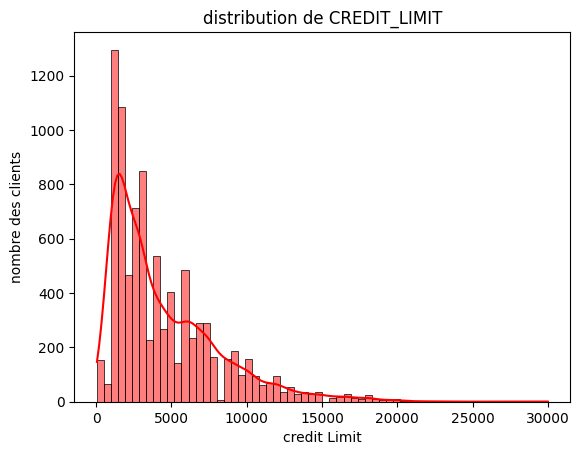

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(data=df,x="CREDIT_LIMIT",kde=True,color='red')

plt.title("distribution de CREDIT_LIMIT")
plt.xlabel("credit Limit")
plt.ylabel("nombre des clients")
plt.show()

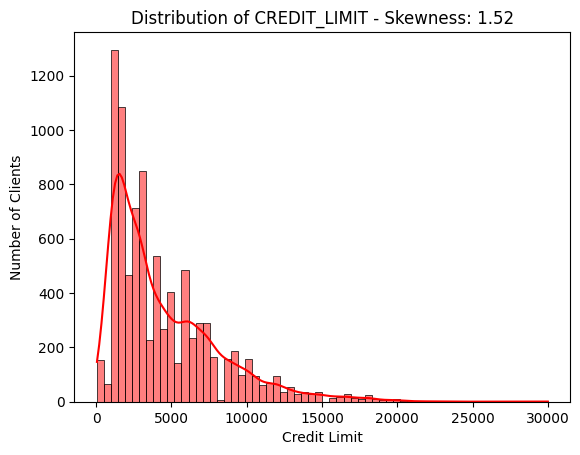

In [ ]:
skew = df["CREDIT_LIMIT"].skew()

sns.histplot(data=df,x="CREDIT_LIMIT",kde=True,color='red')

plt.title(f"distribution of CREDIT_LIMIT - Skewness: {skew:.2f}")
plt.xlabel("Credit Limit")
plt.ylabel("Number of Clients")
plt.show()

In [99]:
from scipy.stats import skew 
skewness = skew(df["CREDIT_LIMIT"],axis=0, bias=True)
print(skewness)

1.522380747924418
